# 06 · Operational review: follow-up on the independent review

Three independent reviewers (fraud-model risk, fraud-operations manager, financial-crime investigator) reviewed notebooks 01–05 and the reports. Their highest-severity findings:
1. **The cost model in notebook 03 assumes every alerted fraud is stopped.** In the triage workflow only the **auto-hold** band stops a transaction at authorisation. Review-band alerts are worked *after* authorisation, so the alerted transaction itself is lost.
2. **Staffing is sized on daily averages and L1 reviews only.** Peaks, overnight auto-holds and L2 / supervisor work are missing.
3. **A 50-a-month random sample below the threshold cannot measure missed fraud.**
4. **Error-rate gaps between demographic groups need confidence intervals and a tolerance.**

This notebook answers each one with the project's own data. Its operational simulation (`src/operations.py`) replaces the notebook-03 cost figure as the **headline business case**. The notebook-03 figure remains as an idealised upper bound.

In [1]:
import sys, pathlib, json, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src import config, metrics, operations as op, plotting, triage, costs
from src.regions import region
from src.plotting import takeaway

plotting.set_style()
pd.set_option("display.width", 220, "display.max_columns", 40, "display.float_format", "{:,.3f}".format)
scores = pd.read_parquet(config.DATA_PROCESSED / "scores.parquet")
va, te = (scores[scores.split == s].reset_index(drop=True) for s in ["validation", "test"])
cut = json.loads((config.REPORTS / "triage_bands.json").read_text())
decision = json.loads((config.REPORTS / "threshold_decision.json").read_text())
M, RULES = "score_LightGBM", "score_Rules baseline"
DAYS = {"validation": metrics.n_days(va.ts), "test": metrics.n_days(te.ts)}

## 1. Simulation assumptions

| Assumption | Value | Why |
|---|---|---|
| Auto-hold | Stops the transaction; if the customer denies it, the card is blocked at once | Held before authorisation |
| Review queues | The alerted transaction goes through. If an analyst confirms fraud, the card is blocked after the **review delay** | Worked after authorisation |
| Review delay | 12 h on average (sensitivity: 4 h and 24 h) | Mix of same-day and 24h service levels |
| Block effect | Stops further fraud on the compromised card for 7 days; genuine spending is declined for 3 days until the replacement card arrives | Fraud comes in bursts of ~10 transactions over ~2 days (notebook 01) |
| Review cost | ${rc:.0f} per reviewed alert | As notebook 03 |
| Auto-hold cost | ${hc:.0f} per hold (automated confirmation) + ${wh:.0f} friction per genuine customer held | Customer-contact cost and goodwill |
| Recovery | {rec:.0%} (sensitivity: 50%) | Conservative |
| Dispositions | Analysts and customers are assumed to classify correctly | Optimistic; covered in Limitations |

**Same policy for rules and model.** Auto-hold is used only at score levels where **validation precision ≥ 95%**; everything else alerted goes to review.

In [2]:
(pd.Series({"review_delay_hours": op.REVIEW_DELAY_HOURS, "episode_days": op.EPISODE_DAYS, "reissue_days": op.REISSUE_DAYS,
            "review_cost": config.REVIEW_COST, "hold_contact_cost": op.HOLD_CONTACT_COST, "wrong_hold_cost": op.WRONG_HOLD_COST,
            "recovery_rate": config.RECOVERY_RATE}).rename("value").to_frame())

,value
review_delay_hours,12.000
episode_days,7.000
reissue_days,3.000
review_cost,5.000
hold_contact_cost,1.000
wrong_hold_cost,10.000
recovery_rate,0.000


In [3]:
# Auto-hold level for the rules: rule-count levels with >= 95% validation precision
rule_prec = va.groupby(RULES).is_fraud.agg(["size", "mean"]).rename(columns={"mean": "precision"})
ok_levels = rule_prec[(rule_prec.index >= 1) & (rule_prec.precision >= 0.95)].index
T_HOLD_RULES = float(ok_levels.min()) if len(ok_levels) else np.inf
print(f"Rules auto-hold level: {T_HOLD_RULES} rules fired" if np.isfinite(T_HOLD_RULES) else "No rule level reaches 95% precision")
rule_prec

Rules auto-hold level: 4.0 rules fired


,size,precision
score_Rules baseline,,
0.000,364508,0.001
1.000,4344,0.122
2.000,1314,0.281
3.000,581,0.649
4.000,258,0.953


## 2. Choose the review threshold on validation (with auto-hold fixed)

The auto-hold cut-off is fixed from notebook 04 (≥95% validation precision). We sweep the **review** threshold and minimise simulated total cost on validation.

Cost-minimising review threshold on validation: 0.1291 (notebook 03 idealised threshold: 0.0084); thresholds within 5% of the minimum cost: 0.0386-0.1291


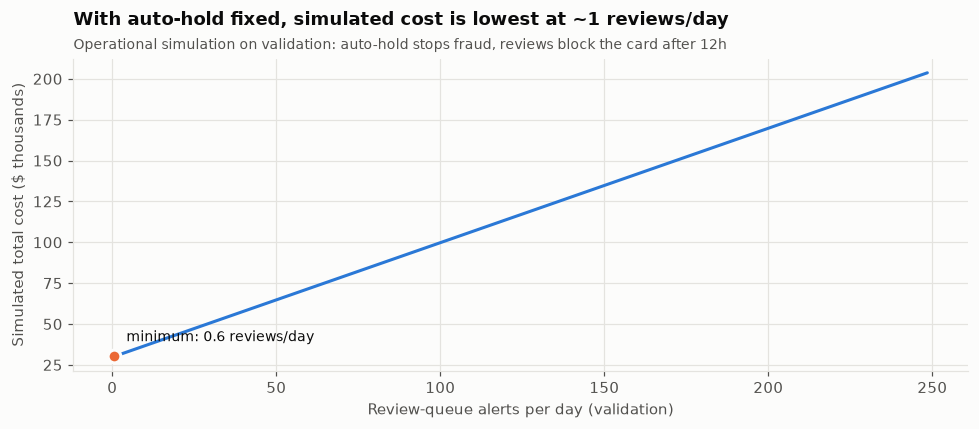

In [4]:
grid = np.unique(np.quantile(va[M], np.linspace(0.90, 0.9995, 250)))
grid = grid[grid < cut["hold"]]
sweep = op.optimise_review_threshold(va, M, cut["hold"], grid)
best = sweep.loc[sweep.total_cost_usd.idxmin()]
T_REVIEW = float(best.t_review)
flat = sweep[sweep.total_cost_usd <= 1.05 * best.total_cost_usd]
print(f"Cost-minimising review threshold on validation: {T_REVIEW:.4f} "
      f"(notebook 03 idealised threshold: {decision['thresholds']['Cost-minimising']:.4f}); "
      f"thresholds within 5% of the minimum cost: {flat.t_review.min():.4f}-{flat.t_review.max():.4f}")
sweep.to_csv(config.REPORTS / "operational_threshold_sweep_validation.csv", index=False)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sweep.reviews_per_day, sweep.total_cost_usd / 1e3, color=plotting.BLUE)
ax.scatter([best.reviews_per_day], [best.total_cost_usd / 1e3], s=70, color=plotting.ORANGE, zorder=4, edgecolor=plotting.SURFACE, linewidth=2)
ax.annotate(f"minimum: {best.reviews_per_day:.1f} reviews/day", (best.reviews_per_day, best.total_cost_usd / 1e3), xytext=(8, 10),
            textcoords="offset points", fontsize=9)
ax.set_xlabel("Review-queue alerts per day (validation)"); ax.set_ylabel("Simulated total cost ($ thousands)")
plotting.title(ax, f"With auto-hold fixed, simulated cost is lowest at ~{best.reviews_per_day:.0f} reviews/day",
               "Operational simulation on validation: auto-hold stops fraud, reviews block the card after 12h")
plotting.save(fig, "operational_cost_curve"); plt.show()

## 3. Operational comparison on test (policies fixed on validation)

In [5]:
T_DESIGN = cut["standard"]          # review line of the triage bands (notebook 04)
policies = {
    "Rules, review only (current process)": (RULES, np.inf, 1.0),
    "Rules + auto-hold (same policy)": (RULES, T_HOLD_RULES, 1.0),
    "LightGBM, review only": (M, np.inf, T_DESIGN),
    "LightGBM + auto-hold, cost-optimal review line": (M, cut["hold"], T_REVIEW),
    "LightGBM + auto-hold, triage bands (recommended)": (M, cut["hold"], T_DESIGN),
}
res, per_card = {}, {}
for name, (col, th, tr) in policies.items():
    res[name], per_card[name] = op.simulate(te, col, th, tr, per_card=True)
ops = pd.DataFrame(res).T
cols = ["fraud_prevented_pct", "fraud_usd_prevented_pct", "fraud_usd_lost", "reviews_per_day", "holds_per_day", "review_precision",
        "wrong_holds", "genuine_declined_after_block", "loss_usd", "review_cost_usd", "hold_cost_usd", "total_cost_usd"]
ops[cols].to_csv(config.REPORTS / "operational_comparison_test.csv")
ops[cols]

,fraud_prevented_pct,fraud_usd_prevented_pct,fraud_usd_lost,reviews_per_day,holds_per_day,review_precision,wrong_holds,genuine_declined_after_block,loss_usd,review_cost_usd,hold_cost_usd,total_cost_usd
"Rules, review only (current process)",0.633,0.676,"239,089.330",43.698,0.000,0.066,0.000,"1,232.000","239,089.330","28,185.000",0.000,"267,274.330"
Rules + auto-hold (same policy),0.694,0.744,"188,774.870",42.953,0.287,0.052,12.000,"1,221.000","188,774.870","27,705.000",157.000,"216,636.870"
"LightGBM, review only",0.730,0.791,"154,493.620",9.550,0.000,0.286,0.000,"1,281.000","154,493.620","6,160.000",0.000,"160,653.620"
"LightGBM + auto-hold, cost-optimal review line",0.962,0.970,"22,012.220",0.519,1.512,0.164,61.000,"1,127.000","22,012.220",335.000,805.000,"23,152.220"
"LightGBM + auto-hold, triage bands (recommended)",0.962,0.970,"22,012.220",6.643,1.442,0.044,61.000,"1,139.000","22,012.220","4,285.000",796.000,"27,093.220"


In [6]:
rec, base_fair, base_cur = "LightGBM + auto-hold, triage bands (recommended)", "Rules + auto-hold (same policy)", "Rules, review only (current process)"
opt_name = "LightGBM + auto-hold, cost-optimal review line"
sav_fair = op.card_bootstrap_saving(per_card[base_fair], per_card[rec])
sav_cur = op.card_bootstrap_saving(per_card[base_cur], per_card[rec])
idealised = costs.sweep(te.is_fraud, te[M], te.amt, DAYS["test"], [decision["thresholds"]["Cost-minimising"]]).iloc[0]
savings = pd.DataFrame({
    "comparison": [f"{rec} vs {base_fair}", f"{rec} vs {base_cur}"],
    "saving_usd": [sav_fair[0], sav_cur[0]], "ci95_low": [sav_fair[1], sav_cur[1]], "ci95_high": [sav_fair[2], sav_cur[2]],
    "test_days": DAYS["test"],
})
savings.to_csv(config.REPORTS / "operational_savings.csv", index=False)
display(savings)
o = ops.loc[rec]; f = ops.loc[base_fair]; cur = ops.loc[base_cur]
takeaway(f"Under the operational simulation on test, the recommended set-up prevents {o.fraud_prevented_pct:.0%} of frauds ({o.fraud_usd_prevented_pct:.0%} of fraud dollars) "
         f"with {o.reviews_per_day:.1f} reviews and {o.holds_per_day:.1f} holds a day. The rules with the same auto-hold policy prevent {f.fraud_prevented_pct:.0%} "
         f"with {f.reviews_per_day:.1f} reviews and {f.holds_per_day:.1f} holds a day. Simulated cost falls by \\${sav_fair[0]:,.0f} over {DAYS['test']} days "
         f"(95% card-bootstrap interval \\${sav_fair[1]:,.0f} to \\${sav_fair[2]:,.0f}). For comparison, the idealised notebook-03 cost of the model was "
         f"\\${idealised.total_cost_usd:,.0f} vs \\${o.total_cost_usd:,.0f} simulated: auto-hold matters, because post-authorisation review only stops the *rest* of a burst.")

,comparison,saving_usd,ci95_low,ci95_high,test_days
0,"LightGBM + auto-hold, triage bands (recommende...","189,543.650","149,957.781","231,378.742",129
1,"LightGBM + auto-hold, triage bands (recommende...","240,181.110","189,230.609","295,658.423",129


**Takeaway:** Under the operational simulation on test, the recommended set-up prevents 96% of frauds (97% of fraud dollars) with 6.6 reviews and 1.4 holds a day. The rules with the same auto-hold policy prevent 69% with 43.0 reviews and 0.3 holds a day. Simulated cost falls by \$189,544 over 129 days (95% card-bootstrap interval \$149,958 to \$231,379). For comparison, the idealised notebook-03 cost of the model was \$21,571 vs \$27,093 simulated: auto-hold matters, because post-authorisation review only stops the *rest* of a burst.

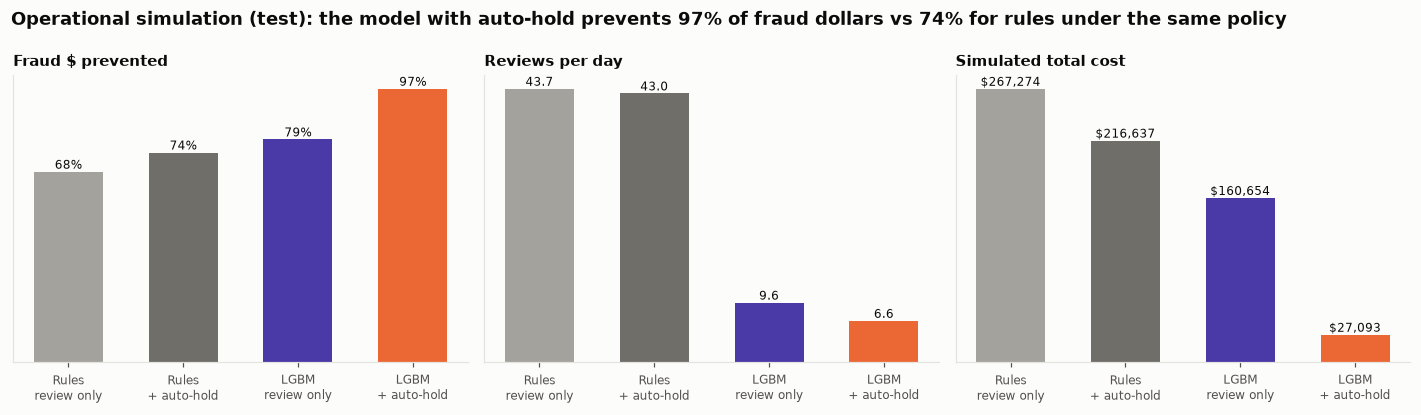

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
order = [base_cur, base_fair, "LightGBM, review only", rec]
short = ["Rules\nreview only", "Rules\n+ auto-hold", "LGBM\nreview only", "LGBM\n+ auto-hold"]
colors = [plotting.NEUTRAL, "#6f6e69", plotting.VIOLET, plotting.ORANGE]
for ax, (col, lab, fmt) in zip(axes, [("fraud_usd_prevented_pct", "Fraud $ prevented", "{:.0%}"),
                                      ("reviews_per_day", "Reviews per day", "{:.1f}"),
                                      ("total_cost_usd", "Simulated total cost", "${:,.0f}")]):
    vals = ops.loc[order, col].astype(float).values
    ax.bar(range(4), vals, color=colors, width=0.6)
    for i, v in enumerate(vals):
        ax.text(i, v, fmt.format(v), ha="center", va="bottom", fontsize=8)
    ax.set_xticks(range(4), short, fontsize=8); ax.set_yticks([]); ax.grid(axis="x", visible=False)
    ax.set_title(lab, loc="left", fontsize=10)
fig.suptitle(f"Operational simulation (test): the model with auto-hold prevents {o.fraud_usd_prevented_pct:.0%} of fraud dollars "
             f"vs {f.fraud_usd_prevented_pct:.0%} for rules under the same policy", x=0.01, ha="left", fontweight="bold")
plotting.save(fig, "operational_comparison"); plt.show()

### Sensitivity of the operational result

In [8]:
sens_rows = []
for label, kw in [("base case", {}), ("review delay 4h", {"delay_hours": 4}), ("review delay 24h", {"delay_hours": 24}),
                  ("wrong-hold cost $0", {"wrong_hold_cost": 0}), ("wrong-hold cost $25", {"wrong_hold_cost": 25}),
                  ("recovery 50%", {"recovery_rate": 0.5}), ("review cost $10", {"review_cost": 10}),
                  ("block stops fraud for 2 days only", {"episode_days": 2})]:
    a = op.simulate(te, M, cut["hold"], T_DESIGN, **kw); b = op.simulate(te, RULES, T_HOLD_RULES, 1.0, **kw)
    sens_rows.append({"scenario": label, "model_cost": a["total_cost_usd"], "rules_same_policy_cost": b["total_cost_usd"],
                      "saving": b["total_cost_usd"] - a["total_cost_usd"], "model_fraud_usd_prevented": a["fraud_usd_prevented_pct"]})
op_sens = pd.DataFrame(sens_rows)
op_sens.to_csv(config.REPORTS / "operational_sensitivity.csv", index=False)
op_sens

,scenario,model_cost,rules_same_policy_cost,saving,model_fraud_usd_prevented
0,base case,"27,093.220","216,636.870","189,543.650",0.970
1,review delay 4h,"26,068.880","197,289.820","171,220.940",0.972
2,review delay 24h,"28,356.280","353,717.240","325,360.960",0.968
3,wrong-hold cost $0,"26,483.220","216,516.870","190,033.650",0.970
4,wrong-hold cost $25,"28,008.220","216,816.870","188,808.650",0.970
5,recovery 50%,"16,087.110","122,249.435","106,162.325",0.970
6,review cost $10,"31,378.220","244,341.870","212,963.650",0.970
7,block stops fraud for 2 days only,"27,093.220","216,636.870","189,543.650",0.970


In [9]:
takeaway(f"The model's advantage holds in every scenario: savings range from \\${op_sens.saving.min():,.0f} to \\${op_sens.saving.max():,.0f} "
         f"over {DAYS['test']} days. The review delay matters most, because a faster review blocks the card earlier in the fraud burst.")

**Takeaway:** The model's advantage holds in every scenario: savings range from \$106,162 to \$325,361 over 129 days. The review delay matters most, because a faster review blocks the card earlier in the fraud burst.

## 4. Staffing by role, peaks and overnight holds

Handling-time assumptions (stated, not measured): L1 review 8 min · L2 confirmation of each fraud case 10 min · supervisor sign-off 5 min per confirmed case · auto-hold confirmation is automated, with 20% needing a 6-min agent call.

In [10]:
daily, hourly = op.daily_workload(te, M, cut["hold"], T_DESIGN)
q = daily.quantile([0.5, 0.95]).T; q["max"] = daily.max()
q.columns = ["median", "p95", "max"]
MIN = {"reviews": 8, "fraud_confirmations": 10 + 5, "holds": 0.2 * 6}
hours = pd.DataFrame({"role": ["L1 analyst (reviews)", "L2 + supervisor (fraud confirmations)", "Customer contact (auto-holds)"],
                      "p95_tasks_per_day": [q.loc["reviews", "p95"], q.loc["fraud_confirmations", "p95"], q.loc["holds", "p95"]]})
hours["p95_hours_per_day"] = hours.p95_tasks_per_day * np.array([MIN["reviews"], MIN["fraud_confirmations"], MIN["holds"]]) / 60
night_share = hourly[[22, 23, 0, 1, 2, 3]].sum() / hourly.sum()
biz_share = hourly[list(range(9, 17))].sum() / hourly.sum()
q.to_csv(config.REPORTS / "operational_daily_workload.csv"); hours.to_csv(config.REPORTS / "operational_staffing.csv", index=False)
display(q); display(hours)
print(f"Auto-holds between 22:00 and 04:00: {night_share:.0%}; between 09:00 and 17:00: {biz_share:.0%}")

,median,p95,max
holds,1.000,3.000,5.000
reviews,6.000,13.000,18.000
fraud_confirmations,1.000,2.600,5.000


,role,p95_tasks_per_day,p95_hours_per_day
0,L1 analyst (reviews),13.000,1.733
1,L2 + supervisor (fraud confirmations),2.600,0.650
2,Customer contact (auto-holds),3.000,0.060


Auto-holds between 22:00 and 04:00: 90%; between 09:00 and 17:00: 2%


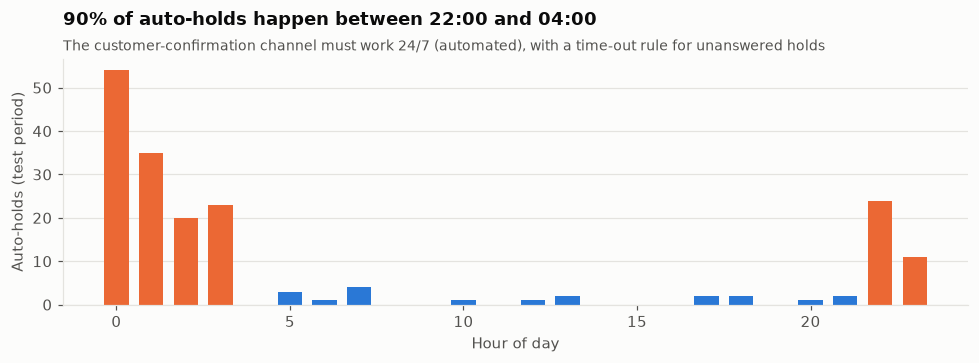

**Takeaway:** On the busiest days (p95) the loss-prevention queues need about 2.4 staff-hours per day across all roles, far below two analysts' ~14 working hours. That leaves room to review the monitor-only band (section 5). But 90% of auto-holds arrive overnight, so the confirmation step must be automated (SMS/app) with a time-out rule: for example, keep the hold and escalate at 08:00 if unanswered.

In [11]:
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(hourly.index, hourly.values, color=[plotting.ORANGE if h in (22, 23, 0, 1, 2, 3) else plotting.BLUE for h in hourly.index], width=0.7)
ax.set_xlabel("Hour of day"); ax.set_ylabel("Auto-holds (test period)"); ax.grid(axis="x", visible=False)
plotting.title(ax, f"{night_share:.0%} of auto-holds happen between 22:00 and 04:00",
               "The customer-confirmation channel must work 24/7 (automated), with a time-out rule for unanswered holds")
plotting.save(fig, "autohold_by_hour"); plt.show()
takeaway(f"On the busiest days (p95) the loss-prevention queues need about {hours.p95_hours_per_day.sum():.1f} staff-hours per day across all roles, "
         f"far below two analysts' ~14 working hours. That leaves room to review the monitor-only band (section 5). But {night_share:.0%} of auto-holds arrive overnight, so the confirmation step must be automated "
         "(SMS/app) with a time-out rule: for example, keep the hold and escalate at 08:00 if unanswered.")

## 5. Measuring missed fraud: sizing the below-threshold review

In [12]:
te_b = te.assign(band=triage.assign_band(te[M], cut))
bt = triage.band_table(te_b, "band", DAYS["test"])
mon_band, no_act = bt.loc["Monitor only"], bt.loc["No action"]
spare = config.DAILY_REVIEW_CAPACITY - o.reviews_per_day
sample = pd.DataFrame({
    "population": ["Monitor-only band (reviewed with spare capacity)", "No-action band (random sample)"],
    "per_day": [mon_band.per_day, no_act.per_day],
    "fraud_rate": [mon_band.fraud_rate_in_band, no_act.fraud_rate_in_band],
    "reviews_needed_per_day": [mon_band.per_day, 50 / 30],
    "expected_frauds_found_per_month": [mon_band.per_day * 30 * mon_band.fraud_rate_in_band, 50 * no_act.fraud_rate_in_band],
})
sample.to_csv(config.REPORTS / "missed_fraud_sampling.csv", index=False)
display(sample)
takeaway(f"Spare L1 capacity is about {spare:.0f} reviews/day. Reviewing the whole monitor-only band ({mon_band.per_day:.0f}/day) fits, and would surface about "
         f"{sample.expected_frauds_found_per_month.iloc[0]:.1f} near-miss frauds a month. A 50-a-month random sample of the no-action band would find "
         f"{sample.expected_frauds_found_per_month.iloc[1]:.3f}, which is useless. Fraud far below the threshold can only be measured through customer-reported fraud and chargebacks.")

,population,per_day,fraud_rate,reviews_needed_per_day,expected_frauds_found_per_month
0,Monitor-only band (reviewed with spare capacity),71.233,0.003,71.233,6.279
1,No-action band (random sample),"2,785.101",0.000,1.667,0.001


**Takeaway:** Spare L1 capacity is about 93 reviews/day. Reviewing the whole monitor-only band (71/day) fits, and would surface about 6.3 near-miss frauds a month. A 50-a-month random sample of the no-action band would find 0.001, which is useless. Fraud far below the threshold can only be measured through customer-reported fraud and chargebacks.

## 6. Fairness with uncertainty

These are error rates at the recommended review threshold on test, with **card-level bootstrap** 95% intervals. Age and gender are not model inputs.

The **proposed tolerances** are for model-risk and compliance to confirm; they are policy choices, not statistical facts:
- the false-alert rate of any group ≤ **1.25x** that of the lowest group
- recall within **3 points** of the best group

A tolerance **fails** only when the whole interval is outside it, and is **inconclusive** when the interval straddles it.

In [13]:
t = te.copy()
t["alert"] = t[M] >= T_DESIGN      # any action: auto-hold or review
t["age_band"] = pd.cut(t.cust_age, [0, 25, 35, 50, 65, 200], right=False, labels=["<25", "25-34", "35-49", "50-64", "65+"]).astype(str)
cards = t.cc_num.unique(); rng = np.random.default_rng(config.SEED)
by_card = {cc: g for cc, g in t.groupby("cc_num")}

def rates(d, col):
    g = d.groupby(col)
    fpr = g.apply(lambda x: (x.alert & (x.is_fraud == 0)).sum() / max((x.is_fraud == 0).sum(), 1), include_groups=False)
    rec = g.apply(lambda x: (x.alert & (x.is_fraud == 1)).sum() / max((x.is_fraud == 1).sum(), 1), include_groups=False)
    return fpr, rec

rows = []
for col in ["gender", "age_band"]:
    fpr0, rec0 = rates(t, col)
    boots_f, boots_r = [], []
    for _ in range(300):
        d = pd.concat([by_card[c] for c in rng.choice(cards, len(cards), replace=True)])
        f_, r_ = rates(d, col)
        boots_f.append(f_ / f_.min()); boots_r.append(r_.max() - r_)
    bf, br = pd.DataFrame(boots_f), pd.DataFrame(boots_r)
    for g in fpr0.index:
        ratio = fpr0[g] / fpr0.min(); gap = rec0.max() - rec0[g]
        lo_f, hi_f = bf[g].quantile([0.025, 0.975]); lo_r, hi_r = br[g].quantile([0.025, 0.975])
        status = lambda lo, hi, tol: "fail" if lo > tol else ("pass" if hi <= tol else "inconclusive")
        rows.append({"attribute": col, "group": g, "false_alerts_per_10k_legit": 1e4 * fpr0[g],
                     "fpr_ratio_vs_lowest": ratio, "ratio_ci": f"{lo_f:.2f}-{hi_f:.2f}", "fpr_tolerance_1.25x": status(lo_f, hi_f, 1.25),
                     "recall": rec0[g], "recall_gap_vs_best_pts": 100 * gap, "gap_ci_pts": f"{100 * lo_r:.1f}-{100 * hi_r:.1f}",
                     "recall_tolerance_3pts": status(100 * lo_r, 100 * hi_r, 3)})
fair = pd.DataFrame(rows)
fair.to_csv(config.REPORTS / "fairness_with_intervals.csv", index=False)
fair

,attribute,group,false_alerts_per_10k_legit,fpr_ratio_vs_lowest,ratio_ci,fpr_tolerance_1.25x,recall,recall_gap_vs_best_pts,gap_ci_pts,recall_tolerance_3pts
0,gender,F,26.680,1.208,1.04-1.47,inconclusive,0.961,2.678,0.8-4.5,inconclusive
1,gender,M,22.093,1.000,1.00-1.00,pass,0.988,0.000,0.0-0.0,pass
2,age_band,25-34,22.944,1.168,1.00-1.56,inconclusive,0.958,4.219,1.5-7.4,inconclusive
3,age_band,35-49,19.636,1.000,1.00-1.28,inconclusive,0.964,3.591,2.1-5.5,inconclusive
4,age_band,50-64,29.288,1.492,1.26-2.02,fail,0.992,0.811,0.0-1.7,pass
5,age_band,65+,32.661,1.663,1.32-2.25,fail,0.967,3.321,0.6-7.0,inconclusive
6,age_band,<25,21.769,1.109,1.00-1.64,inconclusive,1.000,0.000,0.0-0.0,pass


In [14]:
fails = fair[(fair["fpr_tolerance_1.25x"] == "fail") | (fair["recall_tolerance_3pts"] == "fail")]
takeaway(f"{len(fails)} group(s) fail a proposed tolerance outright: "
         + (", ".join(f"{r.attribute}={r.group}" for r in fails.itertuples()) if len(fails) else "none")
         + f"; {((fair['fpr_tolerance_1.25x'] == 'inconclusive') | (fair['recall_tolerance_3pts'] == 'inconclusive')).sum()} are inconclusive. "
         "The model never sees age or gender, so any gap comes through correlated behaviour (spending patterns, time of day). "
         "This is a condition for go-live: compliance must agree the tolerances, and a proxy analysis must identify which features carry the gap.")

**Takeaway:** 2 group(s) fail a proposed tolerance outright: age_band=50-64, age_band=65+; 5 are inconclusive. The model never sees age or gender, so any gap comes through correlated behaviour (spending patterns, time of day). This is a condition for go-live: compliance must agree the tolerances, and a proxy analysis must identify which features carry the gap.

## 7. Summary of review findings and their status

In [15]:
fz = fair.set_index(["attribute", "group"])
worst_age = fair[fair.attribute == "age_band"].sort_values("fpr_ratio_vs_lowest").iloc[-1]
findings = pd.DataFrame([
    ("MR-1", "Model risk + Ops", "High", "Cost model assumed every alerted fraud is stopped; only auto-hold acts before authorisation",
     "Fixed", f"Operational simulation (notebook 06) is the headline: saving ${sav_fair[0]:,.0f} vs rules under the same policy (95% CI ${sav_fair[1]:,.0f}-${sav_fair[2]:,.0f}); notebook-03 figure kept as an idealised upper bound"),
    ("MR-2", "Model risk + Ops", "High", "New fraud patterns are invisible to PSI; a 50-a-month below-threshold sample finds almost nothing",
     "Fixed (design)", f"Review the whole monitor-only band with spare capacity (~{sample.expected_frauds_found_per_month.iloc[0]:.1f} near-miss frauds/month); add score-tail PSI; fast labels from customer reports and dispositions"),
    ("MR-3", "Model risk", "High", "Error-rate gaps by age and gender, with no tolerance defined",
     "Open (condition)", f"Card-bootstrap intervals and proposed tolerances in notebook 06; worst age band {worst_age.group}: {worst_age.fpr_ratio_vs_lowest:.2f}x the lowest false-alert rate (CI {worst_age.ratio_ci}). Compliance sign-off and a proxy analysis are needed before go-live"),
    ("MR-4", "Model risk", "Medium", "SMOTE creates impossible synthetic records (fractional categories and hours) and was compared under a different encoding",
     "Open", "Recommended: switch to class weights or no weighting (validation PR-AUC within 0.005, notebook 02) and re-validate before production"),
    ("MR-5", "Model risk", "Medium", "Validation set reused for early stopping, tuning, imbalance choice and all thresholds",
     "Open", "Test set untouched until the end; validation results are optimistic. Use rolling time-series CV plus a separate threshold window in production"),
    ("MR-6", "Model risk", "Medium", "City population works as a customer identifier; most test cards also appear in train",
     "Open", "Drop or coarsen the feature and validate on unseen cards before production"),
    ("MR-7", "Model risk", "Medium", "Card history length grows with calendar time (tenure / time proxy)",
     "Open", "Documented in the model-risk file; cap or drop before production"),
    ("MR-8", "Model risk", "Medium", "Standard PSI cannot see changes among alerting scores; December 'no retrain' used immature labels",
     "Fixed", "Score-tail PSI and trigger added (notebook 05); December conclusion marked provisional"),
    ("MR-9", "Model risk + Ops", "Medium", "Benchmark rules were built for this project; annualised saving extrapolated from synthetic data",
     "Fixed (wording)", "Rules described as a proxy for the current process; saving reported for the test period with a confidence interval; the annualised figure is removed"),
    ("OPS-1", "Ops", "High", "Capacity check ignored L2, supervisor and customer-contact work, and peak days",
     "Fixed", f"p95-day staffing by role in notebook 06: about {hours.p95_hours_per_day.sum():.1f} staff-hours/day across roles"),
    ("OPS-2", "Ops", "High", "Auto-hold requires immediate customer contact, but most holds are overnight",
     "Fixed (design)", f"{night_share:.0%} of holds are at 22:00-04:00; workflow now specifies automated 24/7 confirmation with a time-out rule"),
    ("OPS-3", "Ops", "Medium", "Headline precision is not what analysts see in the review queues",
     "Fixed", f"Review-queue precision reported separately ({o.review_precision:.0%} in the simulation)"),
    ("OPS-4", "Ops", "Medium", "No friction cost for wrongly held customers; auto-hold was charged as an analyst review",
     "Fixed", f"Simulation charges ${op.HOLD_CONTACT_COST:.0f} per hold + ${op.WRONG_HOLD_COST:.0f} per wrongly held customer ({int(o.wrong_holds)} on test)"),
    ("OPS-5", "Ops", "Low", "The recall-target option missed its 80% target on test",
     "Documented", "Thresholds need a safety margin and must be recalibrated on matured recent data"),
    ("INV-1", "Investigator", "High", "Case report recommended a hold for a priority-review alert",
     "Fixed", "Recommended action now follows the band's workflow (route to L1 priority review; contact before disposition)"),
    ("INV-2", "Investigator", "Medium", "Case selection described inaccurately; the card's earlier confirmed fraud was not reported; no contrary evidence",
     "Fixed", "Selection rule stated; confirmed fraud older than 60 days reported; 'facts that do not fit' section added"),
    ("INV-3", "Investigator", "Low", "Time windows unlabelled; dispositions and roles did not match the workflow; hindsight label in the same file",
     "Fixed", "Windows labelled; dispositions and roles aligned; hindsight outcome moved to a separate file"),
], columns=["id", "reviewer", "severity", "finding", "status", "resolution"])
findings.to_csv(config.REPORTS / "review_findings.csv", index=False)
(config.REPORTS / "review_opinion.md").write_text(
    "**Overall opinion (independent model-risk reviewer): Approved with conditions, for shadow / challenger use only.** "
    "Not approved for live auto-hold decisions until the High findings marked *Open (condition)* are closed and the model is re-validated on the "
    "institution's own data after a 3-month shadow run. **Model risk rating: High (Tier 1).** The reviewer found no temporal leakage.")
findings

,id,reviewer,severity,finding,status,resolution
0,MR-1,Model risk + Ops,High,Cost model assumed every alerted fraud is stop...,Fixed,Operational simulation (notebook 06) is the he...
1,MR-2,Model risk + Ops,High,New fraud patterns are invisible to PSI; a 50-...,Fixed (design),Review the whole monitor-only band with spare ...
2,MR-3,Model risk,High,"Error-rate gaps by age and gender, with no tol...",Open (condition),Card-bootstrap intervals and proposed toleranc...
3,MR-4,Model risk,Medium,SMOTE creates impossible synthetic records (fr...,Open,Recommended: switch to class weights or no wei...
4,MR-5,Model risk,Medium,"Validation set reused for early stopping, tuni...",Open,Test set untouched until the end; validation r...
5,MR-6,Model risk,Medium,City population works as a customer identifier...,Open,Drop or coarsen the feature and validate on un...
6,MR-7,Model risk,Medium,Card history length grows with calendar time (...,Open,Documented in the model-risk file; cap or drop...
7,MR-8,Model risk,Medium,Standard PSI cannot see changes among alerting...,Fixed,Score-tail PSI and trigger added (notebook 05)...
8,MR-9,Model risk + Ops,Medium,Benchmark rules were built for this project; a...,Fixed (wording),Rules described as a proxy for the current pro...
9,OPS-1,Ops,High,"Capacity check ignored L2, supervisor and cust...",Fixed,p95-day staffing by role in notebook 06: about...


In [16]:
summary = {
    "t_review_operational": T_REVIEW, "t_review_design": T_DESIGN, "t_hold": cut["hold"], "t_hold_rules": T_HOLD_RULES,
    "cost_optimal_line": ops.loc[opt_name].to_dict(),
    "recommended": ops.loc[rec].to_dict(), "rules_same_policy": ops.loc[base_fair].to_dict(), "rules_current": ops.loc[base_cur].to_dict(),
    "saving_vs_rules_same_policy": dict(zip(["saving", "ci_low", "ci_high"], sav_fair)),
    "saving_vs_rules_current": dict(zip(["saving", "ci_low", "ci_high"], sav_cur)),
    "idealised_model_cost_nb03": float(idealised.total_cost_usd),
    "night_share_of_holds": float(night_share), "p95_staff_hours": float(hours.p95_hours_per_day.sum()),
    "spare_reviews_per_day": float(spare), "monitor_band_per_day": float(mon_band.per_day),
    "monitor_band_frauds_per_month": float(sample.expected_frauds_found_per_month.iloc[0]),
    "test_days": DAYS["test"],
}
(config.REPORTS / "operational_summary.json").write_text(json.dumps(summary, indent=2, default=float))
{k: v for k, v in summary.items() if not isinstance(v, dict)}

{'t_review_operational': 0.1291434554780085,
 't_review_design': 0.008447008853411628,
 't_hold': 0.24362074234467487,
 't_hold_rules': 4.0,
 'idealised_model_cost_nb03': 21570.98999999941,
 'night_share_of_holds': 0.8978494623655914,
 'p95_staff_hours': 2.443333333333332,
 'spare_reviews_per_day': 93.35658914728683,
 'monitor_band_per_day': 71.23255813953489,
 'monitor_band_frauds_per_month': 6.279069767441861,
 'test_days': 129}